# Day 3

In [54]:
%matplotlib inline

In [1]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib
matplotlib.use("Agg")

In [55]:
import torch
import requests
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image

from transformers import (
    AutoProcessor,
    AutoModelForZeroShotObjectDetection
)

from segment_anything import (
    sam_model_registry,
    SamPredictor
)

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cuda
NVIDIA RTX PRO 4000 Blackwell


In [4]:
USE_STRUCTURE = True
USE_CLIP = True
USE_ADAPTIVE = True

In [5]:
model_id = "IDEA-Research/grounding-dino-tiny"

processor = AutoProcessor.from_pretrained(
    model_id
)

grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    model_id
).to(DEVICE)

print("GroundingDINO loaded")

Loading weights: 100%|███████████████████| 990/990 [00:00<00:00, 8598.78it/s]


GroundingDINO loaded


In [29]:
SAM_CHECKPOINT = "../checkpoints/sam_vit_h_4b8939.pth"

sam = sam_model_registry["vit_h"](
    checkpoint=SAM_CHECKPOINT
)

sam.to(device=DEVICE)

predictor = SamPredictor(sam)

print("SAM loaded")

SAM loaded


In [30]:
class GroundedSAMPipeline:

    def __init__(
        self,
        processor,
        model,
        sam_predictor,
        device
    ):

        self.processor = processor
        self.model = model
        self.predictor = sam_predictor
        self.device = device

    def detect(
        self,
        image_pil,
        text_prompt,
        box_threshold=0.25,
        text_threshold=0.25
    ):

        inputs = self.processor(
            images=image_pil,
            text=text_prompt,
            return_tensors="pt"
        ).to(self.device)

        with torch.no_grad():

            outputs = self.model(**inputs)

        results = self.processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            threshold=box_threshold,
            text_threshold=text_threshold,
            target_sizes=[image_pil.size[::-1]]
        )

        result = results[0]

        return (
            result["boxes"].cpu().numpy(),
            result["scores"].cpu().numpy(),
            result["text_labels"]
        )

    def segment(
        self,
        image_np,
        boxes
    ):

        self.predictor.set_image(image_np)

        masks_list = []

        for box in boxes:

            mask, _, _ = self.predictor.predict(
                point_coords=None,
                point_labels=None,
                box=box.astype(np.float32),
                multimask_output=False
            )

            masks_list.append(mask[0])

        return np.stack(masks_list, axis=0)

    def run(
        self,
        image_pil,
        text_prompt,
        box_threshold=0.25
    ):

        boxes, scores, labels = self.detect(
            image_pil,
            text_prompt,
            box_threshold
        )

        image_np = np.array(
            image_pil.convert("RGB")
        )

        masks = self.segment(
            image_np,
            boxes
        )

        return {
            "image_np": image_np,
            "boxes": boxes,
            "scores": scores,
            "labels": labels,
            "masks": masks
        }

In [31]:
pipeline = GroundedSAMPipeline(
    processor,
    grounding_model,
    predictor,
    DEVICE
)

print("Pipeline ready")

Pipeline ready


In [32]:
image_url = "http://farm1.staticflickr.com/26/100143183_3dc8653fa5_z.jpg"

image_pil = Image.open(
    requests.get(
        image_url,
        stream=True
    ).raw
).convert("RGB")

print(image_pil.size)

(640, 480)


In [34]:
text_prompt = "person. laptop. bottle. cat."

result = pipeline.run(
    image_pil,
    text_prompt,
    box_threshold=0.25
)

print(f"Detected {len(result['labels'])} objects")

for label, score in zip(
    result["labels"],
    result["scores"]
):
    print(label, float(score))

Detected 5 objects
cat 0.8844981789588928
laptop 0.8545318245887756
bottle 0.6600175499916077
person 0.7770666480064392
bottle 0.500056803226471


In [35]:
semantic_scores = []

for score in result["scores"]:

    semantic_scores.append(
        float(score)
    )

print("Semantic scores extracted")
print(semantic_scores)

Semantic scores extracted
[0.8844981789588928, 0.8545318245887756, 0.6600175499916077, 0.7770666480064392, 0.500056803226471]


In [36]:
import cv2
import numpy as np

def compute_structural_score(mask):

    # AREA CONSISTENCY
    area = np.sum(mask)

    normalized_area = min(
        area / 10000.0,
        1.0
    )

    # CONTOUR SMOOTHNESS
    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    perimeter = 0

    if len(contours) > 0:

        perimeter = cv2.arcLength(
            contours[0],
            True
        )

    contour_score = min(
        perimeter / 1000.0,
        1.0
    )

    # EDGE COHERENCE
    edges = cv2.Canny(
        mask.astype(np.uint8) * 255,
        100,
        200
    )

    edge_density = (
        np.sum(edges > 0)
        /
        (mask.shape[0] * mask.shape[1])
    )

    edge_score = min(
        edge_density * 10,
        1.0
    )

    # FINAL STRUCTURAL SCORE
    structural_score = (
        0.4 * normalized_area
        +
        0.3 * contour_score
        +
        0.3 * edge_score
    )

    return float(structural_score)

In [37]:
structural_scores = []

for mask in result["masks"]:

    score = compute_structural_score(
        mask
    )

    structural_scores.append(score)

In [38]:
def compute_uncertainty(confidence):

    uncertainty = 1.0 - float(confidence)
    print(uncertainty)
    return uncertainty

In [39]:
import numpy as np

def softmax(x):

    e_x = np.exp(x - np.max(x))

    return e_x / e_x.sum()


def adaptive_weights(
    semantic_conf,
    structural_score,
    agreement_score
):

    semantic_uncertainty = compute_uncertainty(
        semantic_conf
    )

    adjusted_semantic = (
        semantic_conf
        *
        (1 - semantic_uncertainty)
    )

    scores = np.array([
        adjusted_semantic,
        structural_score,
        agreement_score
    ])

    weights = softmax(scores)

    return {
        "semantic_weight": float(weights[0]),
        "structural_weight": float(weights[1]),
        "agreement_weight": float(weights[2])
    }

In [40]:
import open_clip

In [41]:
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)

tokenizer = open_clip.get_tokenizer(
    "ViT-B-32"
)

clip_model = clip_model.to(DEVICE)

print("CLIP loaded")

CLIP loaded


In [42]:
# Crop helper
def crop_mask_region(image_rgb, mask):

    ys, xs = np.where(mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return None

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    crop = image_rgb[y1:y2, x1:x2]

    return crop

In [43]:
#CLIP scoring

from PIL import Image

def compute_clip_score(crop, text):

    if crop is None:
        return 0.0

    image_pil = Image.fromarray(crop)

    image_input = clip_preprocess(
        image_pil
    ).unsqueeze(0).to(DEVICE)

    text_input = tokenizer(
        [text]
    ).to(DEVICE)

    with torch.no_grad():

        image_features = clip_model.encode_image(
            image_input
        )

        text_features = clip_model.encode_text(
            text_input
        )

        image_features /= image_features.norm(
            dim=-1,
            keepdim=True
        )

        text_features /= text_features.norm(
            dim=-1,
            keepdim=True
        )

        similarity = (
            image_features
            @
            text_features.T
        )

    return similarity.item()

In [44]:
def compute_clip_probabilities(
    crop,
    candidate_labels
):

    image_pil = Image.fromarray(crop)

    image_input = clip_preprocess(
        image_pil
    ).unsqueeze(0).to(DEVICE)

    text_input = tokenizer(
        candidate_labels
    ).to(DEVICE)

    with torch.no_grad():

        image_features = clip_model.encode_image(
            image_input
        )

        text_features = clip_model.encode_text(
            text_input
        )

        image_features /= image_features.norm(
            dim=-1,
            keepdim=True
        )

        text_features /= text_features.norm(
            dim=-1,
            keepdim=True
        )

        similarity = (
            100.0 *
            image_features
            @
            text_features.T
        )

        probs = similarity.softmax(
            dim=-1
        )

    return probs[0].cpu().numpy()

In [45]:
clip_scores = []

clip_labels = []

candidate_labels = [
    "person",
    "laptop",
    "bottle",
    "cat"
]

for i, mask in enumerate(result["masks"]):

    crop = crop_mask_region(
        result["image_np"],
        mask
    )

    probs = compute_clip_probabilities(
        crop,
        candidate_labels
    )

    best_idx = probs.argmax().item()

    best_prob = probs[best_idx].item()

    clip_label = candidate_labels[best_idx]

    clip_scores.append(best_prob)

    clip_labels.append(clip_label)

    print(
        f"[{i+1}] "
        f"CLIP={clip_label} "
        f"({best_prob:.3f})"
    )

[1] CLIP=cat (0.961)
[2] CLIP=laptop (0.995)
[3] CLIP=bottle (0.508)
[4] CLIP=person (0.723)
[5] CLIP=person (0.430)


In [46]:
clip_agreements = []

for i, clip_score in enumerate(clip_scores):

    if clip_score > 0.8:

        agreement = 1.0

    elif clip_score > 0.5:

        agreement = 0.7

    else:

        agreement = 0.3

    clip_agreements.append(agreement)

print("CLIP agreements:")
print(clip_agreements)

CLIP agreements:
[1.0, 1.0, 0.7, 0.7, 0.3]


In [47]:
from scipy.stats import entropy
import numpy as np

def confidence_entropy(scores):

    scores = np.array(scores)

    scores = scores / np.sum(scores)

    return entropy(scores)

In [48]:
def adaptive_structural_arbitration(

    semantic_conf,
    structural_score,
    agreement_score,
    clip_scores

):

    # ENTROPY-BASED RELIABILITY
    clip_entropy = confidence_entropy(
        clip_scores
    )

    # STRUCTURAL BOOST UNDER HIGH SEMANTIC UNCERTAINTY
    if clip_entropy > 0.8:

        structural_score *= 1.2

    # COMPUTE DYNAMIC WEIGHTS
    weights = adaptive_weights(
        semantic_conf,
        structural_score,
        agreement_score
    )

    # FINAL ARBITRATION
    final_score = (

        weights["semantic_weight"]
        * semantic_conf

        +

        weights["structural_weight"]
        * structural_score

        +

        weights["agreement_weight"]
        * agreement_score
    )

    return {
        "final_score": float(final_score),
        "weights": weights,
        "entropy": float(clip_entropy)
    }

In [49]:
asam_results = []

for i, (
    semantic_conf,
    structural_score,
    agreement_score
) in enumerate(

    zip(
        semantic_scores,
        structural_scores,
        clip_agreements
    )
):

    clip_scores = [
        semantic_conf,
        agreement_score,
        structural_score
    ]

    result_item = adaptive_structural_arbitration(

        semantic_conf=semantic_conf,
        structural_score=structural_score,
        agreement_score=agreement_score,
        clip_scores=clip_scores
    )

    asam_results.append(result_item)

0.11550182104110718
0.14546817541122437
0.33998245000839233
0.2229333519935608
0.49994319677352905


In [50]:
for i, result_item in enumerate(asam_results):

    print(
        f"[{i+1}] "
        f"{result['labels'][i]:15} | "
        f"Final={result_item['final_score']:.3f} | "
        f"Entropy={result_item['entropy']:.3f} | "
        f"S={result_item['weights']['semantic_weight']:.2f} | "
        f"St={result_item['weights']['structural_weight']:.2f} | "
        f"A={result_item['weights']['agreement_weight']:.2f}"
    )

[1] cat             | Final=0.917 | Entropy=1.089 | S=0.30 | St=0.32 | A=0.37
[2] laptop          | Final=0.823 | Entropy=1.037 | S=0.32 | St=0.25 | A=0.42
[3] bottle          | Final=0.548 | Entropy=0.901 | S=0.33 | St=0.24 | A=0.43
[4] person          | Final=0.607 | Entropy=0.947 | S=0.36 | St=0.24 | A=0.40
[5] bottle          | Final=0.297 | Entropy=0.816 | S=0.35 | St=0.28 | A=0.37


In [51]:
filtered_masks = []

filtered_labels = []

filtered_scores = []

for i, result_item in enumerate(asam_results):

    final_score = result_item["final_score"]

    entropy = result_item["entropy"]

    adaptive_threshold = (
        0.45
        +
        entropy * 0.05
    )

    if final_score > adaptive_threshold:

        filtered_masks.append(
            result["masks"][i]
        )

        filtered_labels.append(
            result["labels"][i]
        )

        filtered_scores.append(
            final_score
        )

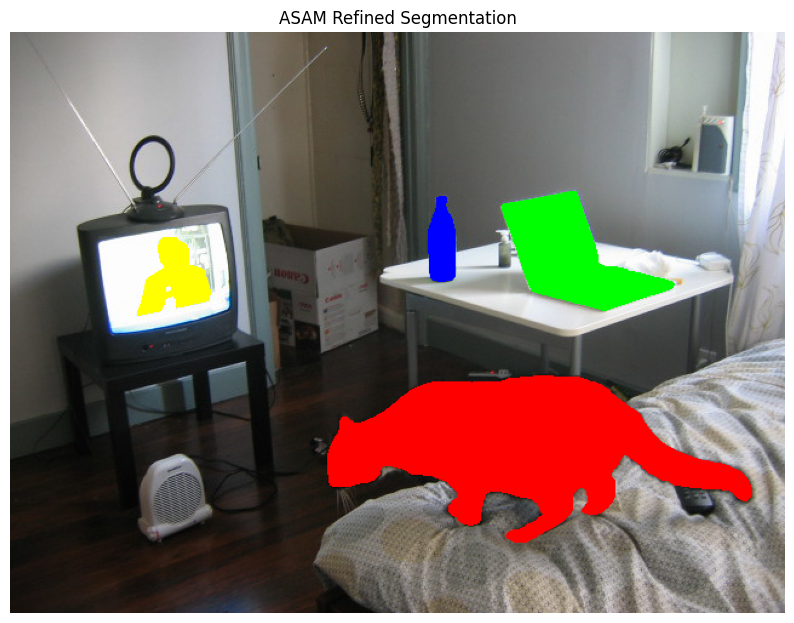

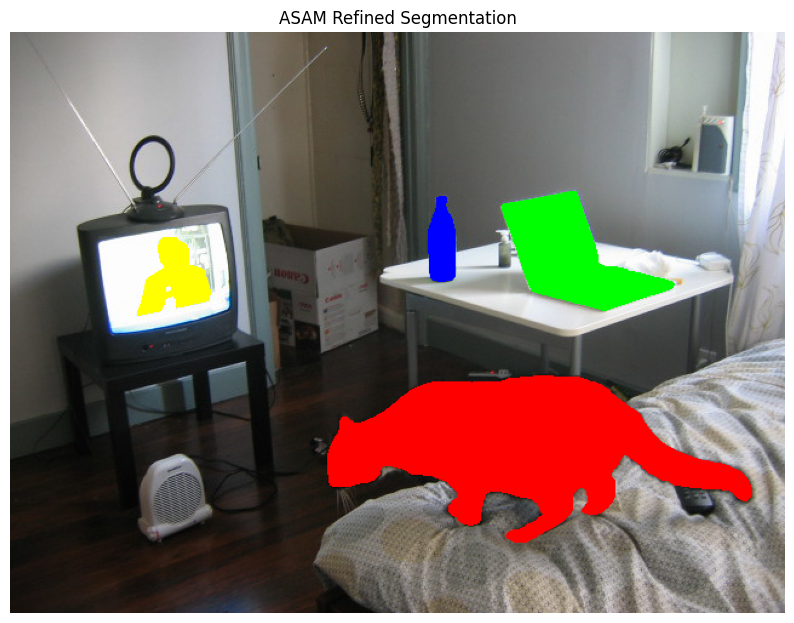

In [56]:
import matplotlib.pyplot as plt
import numpy as np

overlay = result["image_np"].copy()

colors = [
    [255, 0, 0],
    [0, 255, 0],
    [0, 0, 255],
    [255, 255, 0]
]

for i, mask in enumerate(filtered_masks):

    overlay[mask > 0] = colors[
        i % len(colors)
    ]

plt.figure(figsize=(10,10))

plt.imshow(overlay)

plt.title(
    "ASAM Refined Segmentation"
)

plt.axis("off")

plt.show()

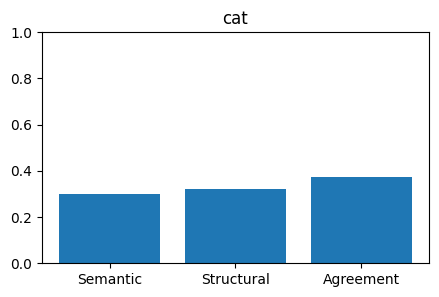

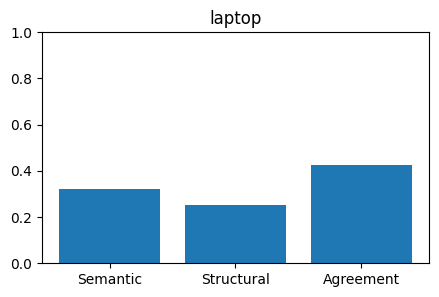

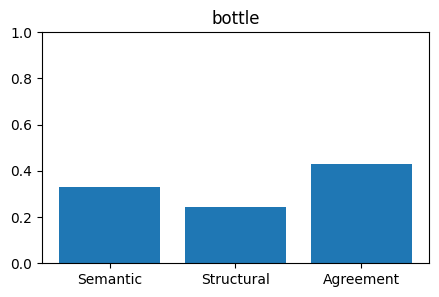

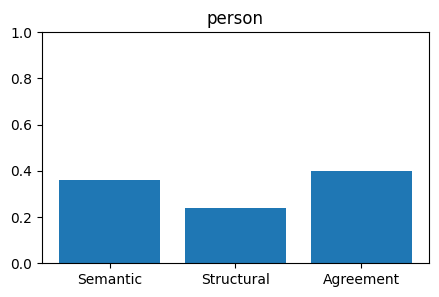

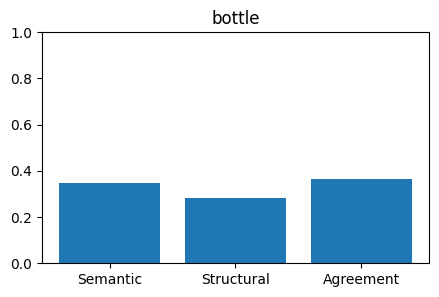

In [57]:
for i, result_item in enumerate(asam_results):

    plt.figure(figsize=(5,3))

    labels = [
        "Semantic",
        "Structural",
        "Agreement"
    ]

    values = [
        result_item["weights"]["semantic_weight"],
        result_item["weights"]["structural_weight"],
        result_item["weights"]["agreement_weight"]
    ]

    plt.bar(labels, values)

    plt.ylim(0,1)

    plt.title(
        f"{result['labels'][i]}"
    )

    plt.show()

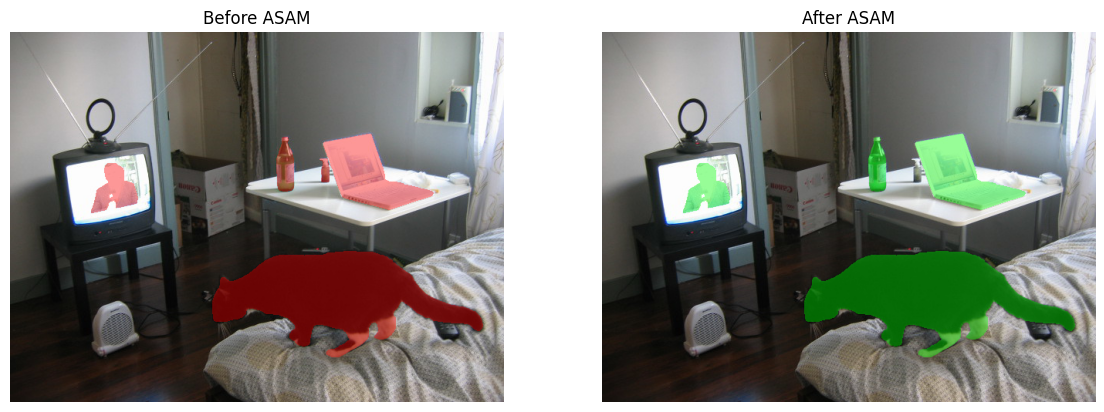

In [60]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(14,7)
)

# BEFORE
before = result["image_np"].copy()

for mask in result["masks"]:

    # before[mask > 0] = [255,0,0]
    before[mask > 0] = (
    0.6 * before[mask > 0]
    +
    0.4 * np.array([255,0,0]))

ax[0].imshow(before)

ax[0].set_title(
    "Before ASAM"
)

ax[0].axis("off")

# AFTER
after = result["image_np"].copy()

for mask in filtered_masks:

    # after[mask > 0] = [0,255,0]
    after[mask > 0] = (
    0.6 * after[mask > 0]
    +
    0.4 * np.array([0,255,0]))

ax[1].imshow(after)

ax[1].set_title(
    "After ASAM"
)

ax[1].axis("off")

plt.show()